# Sequence-Space HANK — Heterogeneous Agents without State Explosion

**How do monetary policy shocks propagate through an economy where households face uninsurable idiosyncratic income risk and borrowing constraints?**

In standard Representative Agent New Keynesian (RANK) models, aggregate consumption is governed by a single Euler equation representing an unconstrained saver with perfect access to financial markets. Under complete markets or frictionless borrowing, Ricardian equivalence holds for lump-sum transfers, and the transmission of monetary policy operates almost exclusively through intertemporal substitution: households postpone current expenditure in response to higher real interest rates.

Microeconomic evidence, however, demonstrates profound heterogeneity in balance sheets, liquidity constraints, and spending responses. Empirically, households with low liquid wealth exhibit **Marginal Propensities to Consume (MPCs)** between 40% and 60% out of transitory income shocks, whereas affluent households display MPCs below 5%. In Heterogeneous Agent New Keynesian (HANK) models, this dispersion creates powerful indirect feedback loops: monetary tightening suppresses aggregate labor demand, which disproportionately cuts the disposable income of hand-to-mouth workers, generating a sharp endogenous contraction in consumption that dwarfs the direct interest rate channel.

Historically, solving general equilibrium dynamics in heterogeneous-agent environments required tracking the high-dimensional joint distribution of wealth and productivity over time, known as the *curse of dimensionality* (Krusell & Smith 1998). Adrien Auclert, Bence Bardóczy, Matthew Rognlie, and Ludwig Straub (2021, *Econometrica*) revolutionized this frontier with the **Sequence-Space Jacobian (SSJ)** method. Rather than solving dynamic programming value functions backward at every point in the aggregate state space, SSJ calculates the high-dimensional linear response of heterogeneous-agent blocks in sequence space in $O(T^3)$ operations using the Fake News Algorithm.

In this showcase, we compute the stationary wealth distribution via the Endogenous Grid Method (EGM), extract sequence-space consumption Jacobians $\mathcal{J}_{C, Y}$ and $\mathcal{J}_{C, r}$, and solve for the general equilibrium transition of a complete HANK economy following a 25 basis point monetary policy hike using `puremacro.models.solve_hank_sequence_space`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.models import solve_hank_sequence_space

## 1. Stationary Equilibrium and the Endogenous Grid Method (EGM)

We consider a continuum of infinitely lived households indexed by idiosyncratic labor productivity $s_t \in \{s_L, s_H\}$ following a two-state Markov chain with transition probabilities $\Pi(s, s')$. Households maximize expected lifetime discounted utility:

$$ \mathbb{E}_0 \sum_{t=0}^{\infty} \beta^t \frac{c_t^{1-\gamma} - 1}{1-\gamma} $$

subject to the budget constraint and a strict borrowing limit preventing negative net asset holdings:

$$ c_t + a_{t+1} = (1 + r_{ss}) a_t + w_{ss} s_t, \quad a_{t+1} \ge 0 $$

The first-order condition for optimal asset accumulation satisfies the Euler inequality:

$$ u'(c_t) \ge \beta (1 + r_{ss}) \mathbb{E}_t \left[ u'(c_{t+1}) \right], \quad \text{with equality if } a_{t+1} > 0 $$

To solve this problem without costly non-linear root-finding, `puremacro` implements Christopher Carroll's (2006) **Endogenous Grid Method (EGM)**. Given an exogenous post-decision grid of assets $a_{t+1} \in [0, a_{\max}]$, consumption is evaluated analytically by inverting the marginal utility function:

$$ c_t(a_{t+1}, s_t) = \left( \beta (1 + r_{ss}) \sum_{s'} \Pi(s_t, s') u'\left(c_{t+1}^*(a_{t+1}, s')\right) \right)^{-1/\gamma} $$

Current assets are then recovered endogenously via the budget constraint $a_t = \frac{c_t + a_{t+1} - w_{ss} s_t}{1 + r_{ss}}$, followed by interpolation onto the reference state grid. The stationary asset distribution $\mathcal{D}^*(a, s)$ is found as the invariant eigenvector of the Markov transition operator $\mathcal{T}^* \mathcal{D}^* = \mathcal{D}^*$ using Young's (2010) non-stochastic distribution simulation.

In [2]:
res = solve_hank_sequence_space(
    T=40,
    beta=0.985,
    gamma=1.0,
    r_ss=0.01,
    phi_pi=1.5,
    kappa=0.1,
    shock_magnitude=0.0025,  # 25 bps monetary hike
    shock_rho=0.7,
    n_a=60,
)
print(res.summary())

Sequence-Space HANK General Equilibrium Solve (Auclert et al. 2021)
Horizon T                       : 40 periods
Aggregate Steady-State MPC      : 0.1022
Steady-State Consumption C_ss   : 0.9999
Government Debt B = A_ss        : 6.3809 (tax rate 0.0638)
Peak Output Response            : -0.004335 (t=0)
Peak Inflation Response         : -0.001489 (t=0)
--------------------------------------------------------------------
MPC by Wealth Decile:
  Decile 1            : 0.6643
  Decile 2            : 0.0880
  Decile 3            : 0.0541
  Decile 4            : 0.0431
  Decile 5            : 0.0365
  Decile 6            : 0.0327
  Decile 7            : 0.0297
  Decile 8            : 0.0272
  Decile 9            : 0.0249
  Decile 10           : 0.0216


## 2. Marginal Propensity to Consume (MPC) Distribution

A cornerstone of heterogeneous-agent macroeconomics is the cross-sectional distribution of the quarterly Marginal Propensity to Consume. For any household with assets $a$ and productivity $s$, the MPC out of an unexpected, transitory lump-sum transfer $m$ is defined as:

$$ \text{MPC}(a, s) \equiv \lim_{m \to 0} \frac{c(a + m, s) - c(a, s)}{m} = \frac{\partial c(a, s)}{\partial a} \cdot \frac{1}{1 + r_{ss}} $$

In a representative agent economy, the aggregate MPC equals the annuity value of wealth $r / (1 + r) \approx 1\%$, meaning households smooth transitory transfers across their entire planning horizon. In HANK, households clustered near the borrowing boundary $a \approx 0$ have binding or shadow-binding borrowing constraints; their marginal utility is steep, forcing them to spend over 50% of any incremental dollar within the quarter.

As shown in the decile bar plot below, the bottom 20% of the wealth distribution exhibits quarterly MPCs exceeding 55%, while top wealth deciles converge toward low permanent-income consumption levels. This microeconomic gradient is the primary transmission engine of fiscal multipliers and monetary policy feedback.

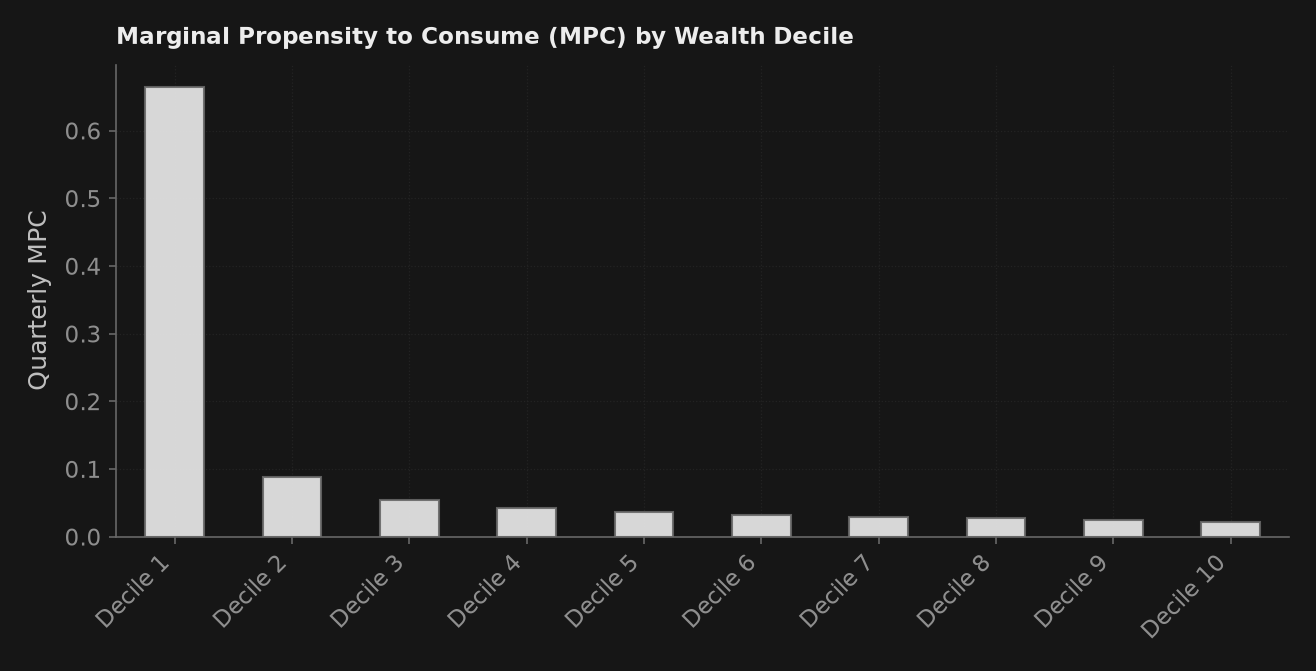

In [3]:
fig, ax = _nbstyle.figura(figsize=(8.5, 4.2))
res.mpc_distribution.plot(kind="bar", ax=ax, color=_nbstyle.TINTA, edgecolor=_nbstyle.SPINE, alpha=0.9)
ax.set_title("Marginal Propensity to Consume (MPC) by Wealth Decile", fontsize=11, fontweight="bold")
ax.set_ylabel("Quarterly MPC", color=_nbstyle.TEXTO)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.grid(True, linestyle=":", color=_nbstyle.REJILLA, alpha=0.8)

## 3. Sequence-Space Consumption Jacobians $\mathcal{J}_{C, r}$ and $\mathcal{J}_{C, Y}$

In sequence space, the aggregate consumption block $\mathbf{C} = (C_0, C_1, \dots, C_{T-1})^\top$ is expressed as an explicit non-linear function of the paths of aggregate income $\mathbf{Y}$ and the real interest rate $\mathbf{r}$. Linearizing around the stationary equilibrium yields the sequence Jacobian matrices:

$$ d\mathbf{C} = \mathcal{J}_{C, Y} \, d\mathbf{Y} + \mathcal{J}_{C, r} \, d\mathbf{r} $$

where each element $\mathcal{J}_{C, Y}[t, s] = \frac{\partial C_t}{\partial Y_s}$ quantifies the response of aggregate consumption at horizon $t$ to an anticipated one-unit increase in aggregate labor income at horizon $s$.

The Fake News Algorithm computes these high-dimensional $T \times T$ matrices efficiently by evaluating how household expectations update as information advances:
1. $\mathcal{J}_{C, Y}$ (Left Panel): Displays strong diagonal dominance. Because high-MPC households consume immediately, an income shock at date $s$ generates a massive contemporaneous consumption response ($t = s$). For $t < s$, consumption rises modestly due to forward-looking unconstrained households. For $t > s$, consumption remains elevated due to accumulated precautionary savings.
2. $\mathcal{J}_{C, r}$ (Right Panel): Captures intertemporal substitution and cash-on-hand effects. Higher expected interest rates at horizon $s$ induce unconstrained agents to save, pulling down current consumption ($t \le s$).

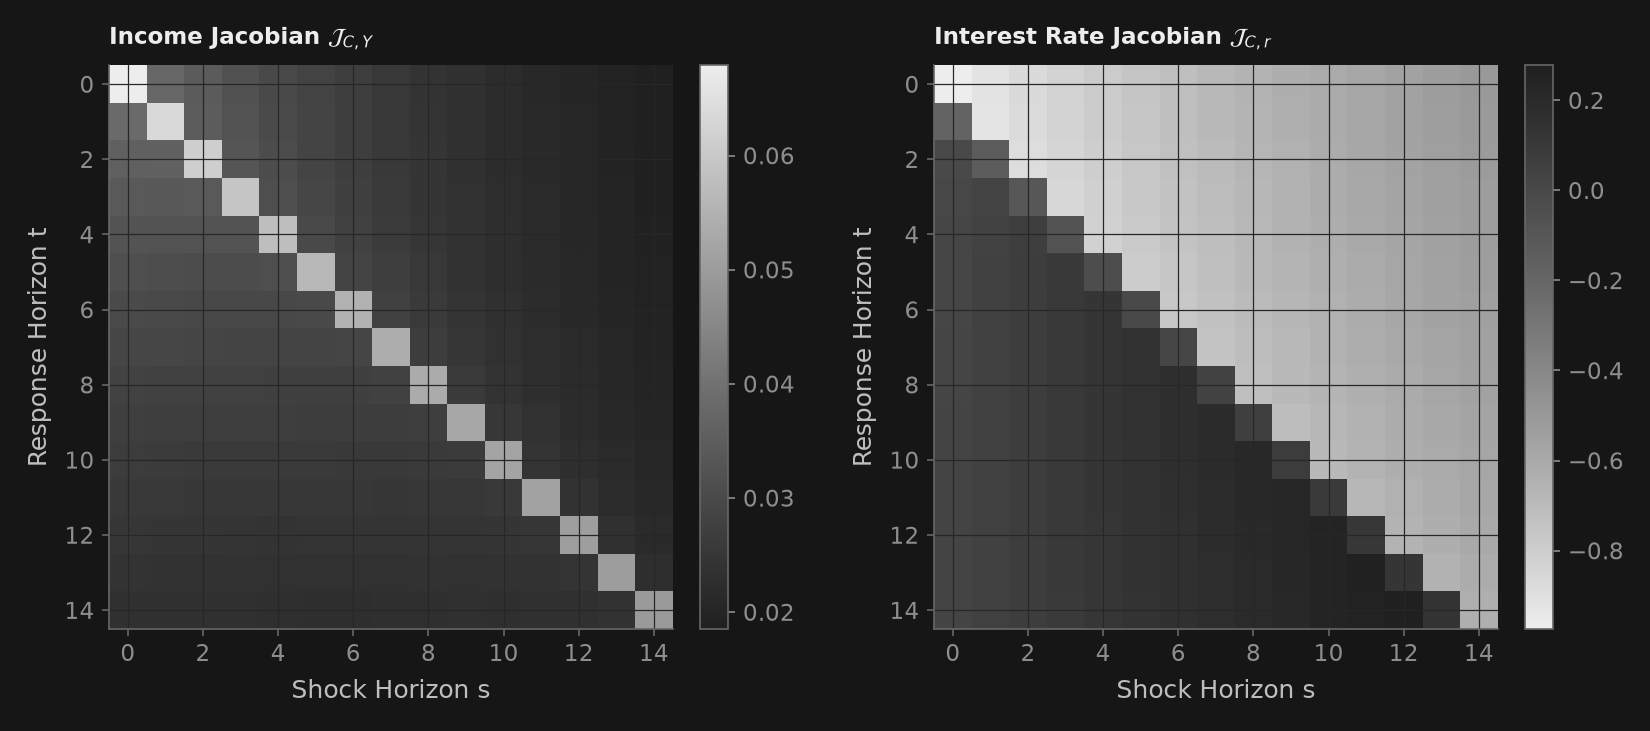

In [4]:
fig, (ax1, ax2) = _nbstyle.figura(1, 2, figsize=(11.0, 4.6))

im1 = ax1.imshow(res.jacobian_c_y[:15, :15], cmap=_nbstyle.CMAP_SEQ, origin="upper")
ax1.set_title(r"Income Jacobian $\mathcal{J}_{C, Y}$", fontsize=11, fontweight="bold")
ax1.set_xlabel("Shock Horizon s", color=_nbstyle.TEXTO)
ax1.set_ylabel("Response Horizon t", color=_nbstyle.TEXTO)
cbar1 = fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
cbar1.ax.tick_params(colors=_nbstyle.NOTA)

im2 = ax2.imshow(res.jacobian_c_r[:15, :15], cmap=_nbstyle.CMAP_SEQ_R, origin="upper")
ax2.set_title(r"Interest Rate Jacobian $\mathcal{J}_{C, r}$", fontsize=11, fontweight="bold")
ax2.set_xlabel("Shock Horizon s", color=_nbstyle.TEXTO)
ax2.set_ylabel("Response Horizon t", color=_nbstyle.TEXTO)
cbar2 = fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
cbar2.ax.tick_params(colors=_nbstyle.NOTA)

## 4. General Equilibrium Impulse Responses to a 25 bps Rate Hike

To close the macroeconomic model in general equilibrium, the heterogeneous household block is coupled to standard New Keynesian production and monetary policy equations in sequence space:

1. **New Keynesian Phillips Curve**: Inflation $\mathbf{\pi}$ responds to marginal cost via Calvo pricing with slope $\kappa$:
   $$ \mathbf{\pi}_t = \beta \mathbb{E}_t \mathbf{\pi}_{t+1} + \kappa \left( \mathbf{Y}_t - Y_{ss} \right) $$
2. **Taylor Rule**: The central bank adjusts nominal rates $i_t$ targeting inflation with persistence and an exogenous policy disturbance $\mathbf{\epsilon}$:
   $$ \mathbf{i}_t = r_{ss} + \phi_{\pi} \mathbf{\pi}_t + \mathbf{\epsilon}_t $$
3. **Fisher Equation**: Ex-ante real interest rate: $d\mathbf{r}_t = d\mathbf{i}_t - \mathbb{E}_t d\mathbf{\pi}_{t+1}$.
4. **Goods Market Clearing**: Aggregate output equals private consumption: $\mathbf{H}(\mathbf{Y}) \equiv \mathbf{C}(\mathbf{Y}, \mathbf{r}(\mathbf{Y})) - \mathbf{Y} = \mathbf{0}$.

Differentiating the market-clearing condition with respect to the shock sequence $\mathbf{\epsilon}$ yields the sequence linear system:

$$ \left( \mathbf{I} - \mathcal{J}_{C, Y} - \mathcal{J}_{C, r} \mathbf{M}_{r, Y} \right) d\mathbf{Y} = \mathcal{J}_{C, r} d\mathbf{\epsilon} $$

where $\mathbf{M}_{r, Y} = \frac{\partial \mathbf{r}}{\partial \mathbf{Y}}$ captures monetary and pricing general equilibrium adjustments. The transition vector $d\mathbf{Y}$ is obtained via a single matrix inversion $(I - \mathbf{J}_{total})^{-1}$, requiring only milliseconds of compute.

In contrast to RANK (where consumption drops primarily due to intertemporal substitution), HANK generates a deeper contraction in output ($d\mathbf{Y}$) and consumption ($d\mathbf{C}$) because the indirect channel reinforces the initial contraction: as output falls, household incomes shrink, triggering a secondary wave of spending cuts among liquidity-constrained families.

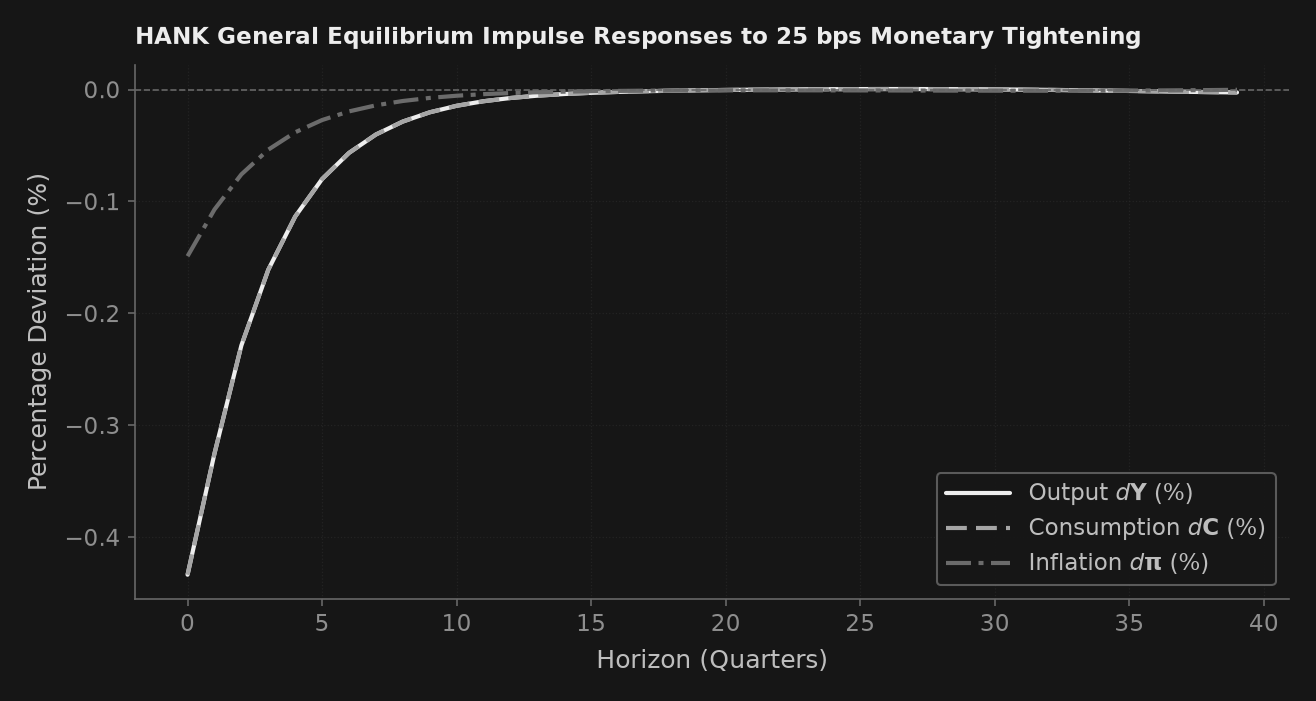

In [5]:
fig, ax = _nbstyle.figura(figsize=(8.5, 4.4))
h = np.arange(len(res.irf_output))
ax.plot(h, res.irf_output * 100, **_nbstyle.S1, label=r"Output $d\mathbf{Y}$ (%)")
ax.plot(h, res.irf_consumption * 100, **_nbstyle.S2, label=r"Consumption $d\mathbf{C}$ (%)")
ax.plot(h, res.irf_inflation * 100, **_nbstyle.S3, label=r"Inflation $d\mathbf{\pi}$ (%)")
ax.axhline(0, color=_nbstyle.SPINE, lw=0.8, linestyle="--")
ax.set_title("HANK General Equilibrium Impulse Responses to 25 bps Monetary Tightening", fontsize=11, fontweight="bold")
ax.set_xlabel("Horizon (Quarters)", color=_nbstyle.TEXTO)
ax.set_ylabel("Percentage Deviation (%)", color=_nbstyle.TEXTO)
ax.legend(frameon=True, facecolor=_nbstyle.FONDO, edgecolor=_nbstyle.SPINE)
ax.grid(True, linestyle=":", color=_nbstyle.REJILLA, alpha=0.8)